In [1]:
# Library imports
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx # NNs and other useful bits --> https://docs.kidger.site/equinox/
import optax  # Optimisers for NN --> https://github.com/deepmind/optax
import matplotlib.pyplot as plt
from tqdm import tqdm
import scipy.io as sio

# Neural Operator Tutorial 1

### Darcy Flow

In this notebook, we will solve a 2D steady-state Darcy flow problem using a DeepONet model. During the tutorial, you will learn the following:


#### Problem Description
We will solve a 2D steady state Darcy flow PDE on a unit square, with the following form:
\begin{equation}
    -\nabla \cdot (a(x) \nabla u(x)) = f(x), \quad x \in [0, 1]^2
\end{equation}

with Dirichlet BC, 
\begin{equation}
    u(x) = 0, \quad x \in \partial [0, 1]^2
\end{equation}

where $u(x)$ is the flow pressure, $a(x)$ is the diffusivity field and $f(x)$ is the forcing function. 

The Darcy PDE describes the flow of a fluid through a porous medium, and is similar to the Heat equation we investigated earlier. However, instead of modelling the diffusion of heat through a region, we are investigating the flow of a fluid. 

We will develop a data-driven deep operator network, $G$, that learns a mapping between $a(x)$ and $u(x)$.

#### Loading Our Dataset

The dataset is openly available from the [Fourier Neural Operator package](https://pypi.org/project/fourier-neural-operator/). We will download the [Darcy dataset](https://drive.google.com/file/d/1ViDqN7nc_VCnMackiXv_d7CHZANAFKzV/view?usp=drive_link), which is saved as keyed pairs where the inputs (keyed 'coeff') are $a(x)$ and the outputs (keyed 'sol') are $u(x)$ at each point on the 2D domain. This domain is discretized at a resolution of $241 \times 241$.

In [2]:
# Loading data
mat_contents_train = sio.loadmat("./data/piececonst_r241_N1024_smooth1.mat")
mat_contents_test = sio.loadmat("./data/piececonst_r241_N1024_smooth2.mat")

We then coarsen this resolution to $49 \times 49$ to generate our training and test datasets. The training and test sets contains $1024$ and $100$ different pairs of $a$ and $u$ functions that are discreetly represented on this coarsened domain.

In [3]:
r = 5
h = int(((421 - 1)/r) + 1)
s = h

a_train = jnp.asarray(mat_contents_train["coeff"])[:,::r,::r][:,:h,:h]
u_train = jnp.asarray(mat_contents_train["sol"])[:,::r,::r][:,:h,:h]

a_test = jnp.asarray(mat_contents_test["coeff"])[:100,::r,::r][:,:h,:h]
u_test = jnp.asarray(mat_contents_test["sol"])[:100,::r,::r][:,:h,:h]

print(f"TRAINING: Input function, $a$, has shape: {a_train.shape}, the solution, $u$, has shape: {u_train.shape}.")
print(f"TESTING: Input function, $a$, has shape: {a_test.shape}, the solution, $u$, has shape: {u_test.shape}.")

TRAINING: Input function, $a$, has shape: (1024, 49, 49), the solution, $u$, has shape: (1024, 49, 49).
TESTING: Input function, $a$, has shape: (100, 49, 49), the solution, $u$, has shape: (100, 49, 49).


We then visualize the first pair of $a$ and $u$ below:

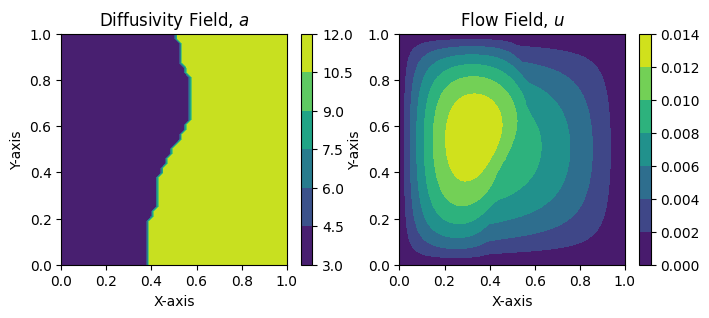

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3))

x = jnp.linspace(0, 1, num=a_train.shape[-1])
xx, yy = jnp.meshgrid(x, x)

# Contour plot for diffusivity coefficient, $a$, and pressure flow field, $u$
a_cs = axs[0].contourf(xx, yy, a_train[0].squeeze())
u_cs = axs[1].contourf(xx, yy, u_train[0].squeeze())

# Adding labels and title
axs[0].set_xlabel('X-axis')
axs[0].set_ylabel('Y-axis')
axs[0].set_title(r'Diffusivity Field, $a$')
axs[1].set_xlabel('X-axis')
axs[1].set_ylabel('Y-axis')
axs[1].set_title(r'Flow Field, $u$')

fig.colorbar(a_cs)
fig.colorbar(u_cs)

### References

1. [Fourier Neural Operator for Parametric Partial Differential Equations](https://arxiv.org/pdf/2010.08895)
2. [Fourier Neural Operator package](https://pypi.org/project/fourier-neural-operator/)